# 4. Propriedades Avançadas e Robustez
Neste último notebook, testamos empiricamente as teorias modernas de Redes Complexas. Avaliamos se o Memetracker obedece à dinâmica de *Small-World*, se a distribuição de graus segue uma *Lei de Potência* (Power Law), e simulamos o colapso da infraestrutura sob ataques randômicos e direcionados aos Hubs.

In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import random
import collections

# 1. CARREGANDO DADOS E LCC
print("Carregando arestas...")
df = pd.read_csv('../data/edges_2days.csv', on_bad_lines='skip')
G_dir = nx.from_pandas_edgelist(df, source='source', target='target', create_using=nx.DiGraph())
G_undir = G_dir.to_undirected()
G_undir.remove_edges_from(nx.selfloop_edges(G_undir))

connected_components = list(nx.connected_components(G_undir))
lcc_nodes = max(connected_components, key=len)
LCC = G_undir.subgraph(lcc_nodes).copy()

N = LCC.number_of_nodes()
E = LCC.number_of_edges()
print(f"LCC extraída com sucesso: {N} Vértices, {E} Arestas")

Carregando arestas...
LCC extraída com sucesso: 321645 Vértices, 596233 Arestas


### O Fenômeno Small-World
Comparamos a Clusterização (C) e o Caminho Médio (L) da nossa rede com um grafo puramente **aleatório** (Erdős-Rényi) equivalente.

In [2]:
def approx_average_path_length(G, sample_size=50):
    if G.number_of_nodes() == 0: return 0
    sampled_nodes = random.sample(list(G.nodes()), min(sample_size, G.number_of_nodes()))
    path_lengths = []
    for n in sampled_nodes:
        lengths = nx.single_source_shortest_path_length(G, n)
        if len(lengths) > 1:
            path_lengths.extend(list(lengths.values())[1:])
    return np.mean(path_lengths) if path_lengths else 0

k_avg = 2 * E / N
print(f"Grau médio <k>: {k_avg:.4f}")

print("Amostrando LCC para Clusterização (10k nós)...")
sampled_cluster_nodes = random.sample(list(LCC.nodes()), min(10000, N))
C_real = nx.average_clustering(LCC, nodes=sampled_cluster_nodes)

print("Amostrando LCC para Caminho Médio (50 nós)...")
L_real = approx_average_path_length(LCC, 50)

C_rand = k_avg / N
L_rand = np.log(N) / np.log(k_avg) if k_avg > 1 else 0

sigma = (C_real / C_rand) / (L_real / L_rand) if C_rand > 0 and L_rand > 0 else 0

print("\n--- Resultados Small-World ---")
print(f"Clusterização Real (C): {C_real:.6f} | Aleatório (C_rand): {C_rand:.6f}")
print(f"Caminho Médio Real (L): {L_real:.4f} | Aleatório (L_rand): {L_rand:.4f}")
print(f"Índice Sigma (Small-worldness): {sigma:.2f} (Valores > 1 indicam forte Small-World)")

Grau médio <k>: 3.7074
Amostrando LCC para Clusterização (10k nós)...
Amostrando LCC para Caminho Médio (50 nós)...

--- Resultados Small-World ---
Clusterização Real (C): 0.041539 | Aleatório (C_rand): 0.000012
Caminho Médio Real (L): 13.8051 | Aleatório (L_rand): 9.6779
Índice Sigma (Small-worldness): 2526.42 (Valores > 1 indicam forte Small-World)


### Lei de Potência (Power Law)
A distribuição de graus das Redes Complexas na vida real costuma não ser uma Curva de Sino (Normal), mas sim uma curva exponencial assintótica que forma uma reta no plano Log-Log.

Expoente Gamma (gamma): 1.6956
R-squared (aderência): 0.7817


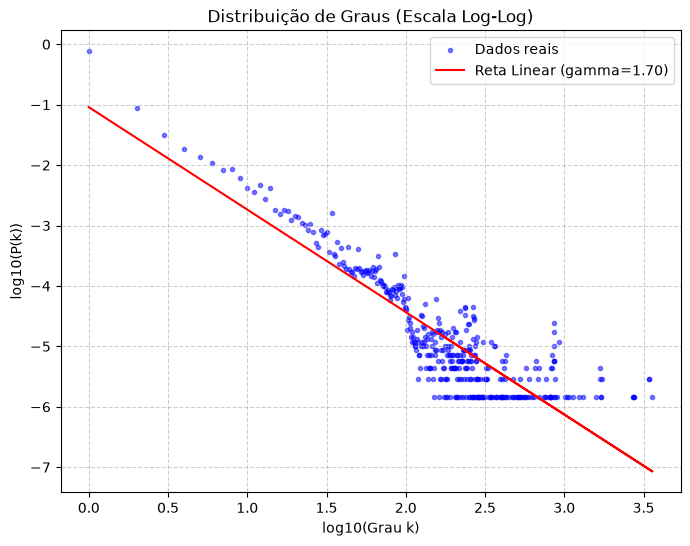

In [3]:
degree_sequence = [d for n, d in G_undir.degree()]
counts = collections.Counter(degree_sequence)

x_k, y_pk = [], []
total_nodes = G_undir.number_of_nodes()

for k, freq in counts.items():
    if k > 0:
        x_k.append(np.log10(k))
        y_pk.append(np.log10(freq / total_nodes))
        
slope, intercept, r_value, p_value, std_err = st.linregress(x_k, y_pk)
gamma = -slope

print(f"Expoente Gamma (gamma): {gamma:.4f}")
print(f"R-squared (aderência): {r_value**2:.4f}")

plt.figure(figsize=(8,6))
plt.scatter(x_k, y_pk, alpha=0.5, label='Dados reais', color='b', marker='.')
plt.plot(x_k, intercept + slope * np.array(x_k), 'r', label=f'Reta Linear (gamma={gamma:.2f})')
plt.title("Distribuição de Graus (Escala Log-Log)")
plt.xlabel("log10(Grau k)")
plt.ylabel("log10(P(k))")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Simulação de Robustez
Vamos realizar um teste de estresse na LCC destruindo 5% de seus nós ($r = 16.082$ vértices). O primeiro ataque será cego e aleatório (30 repetições). O segundo ataque será cirúrgico, destruindo especificamente os Hubs de maior grau.

Destruindo 16082 nós aleatórios em 30 rodadas...
Realizando Ataque Direcionado aos 5% Top Hubs...

--- RESULTADOS GERAIS DE ROBUSTEZ ---
Tamanho da Maior Componente (A) - Aleatório: 280037.3 | Ataque: 1986
Fracao de Nós Isolados (D)      - Aleatório: 3.93% | Ataque: 76.38%


C:\Users\XxThe\AppData\Local\Temp\ipykernel_26248\4200535637.py:53: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=True, patch_artist=True)
C:\Users\XxThe\AppData\Local\Temp\ipykernel_26248\4200535637.py:53: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=True, patch_artist=True)
C:\Users\XxThe\AppData\Local\Temp\ipykernel_26248\4200535637.py:53: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=True, patch_artist=True)
C:\Users\XxThe\AppData\Local\Temp\ipykernel_26248\4200535637.py:53: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use or

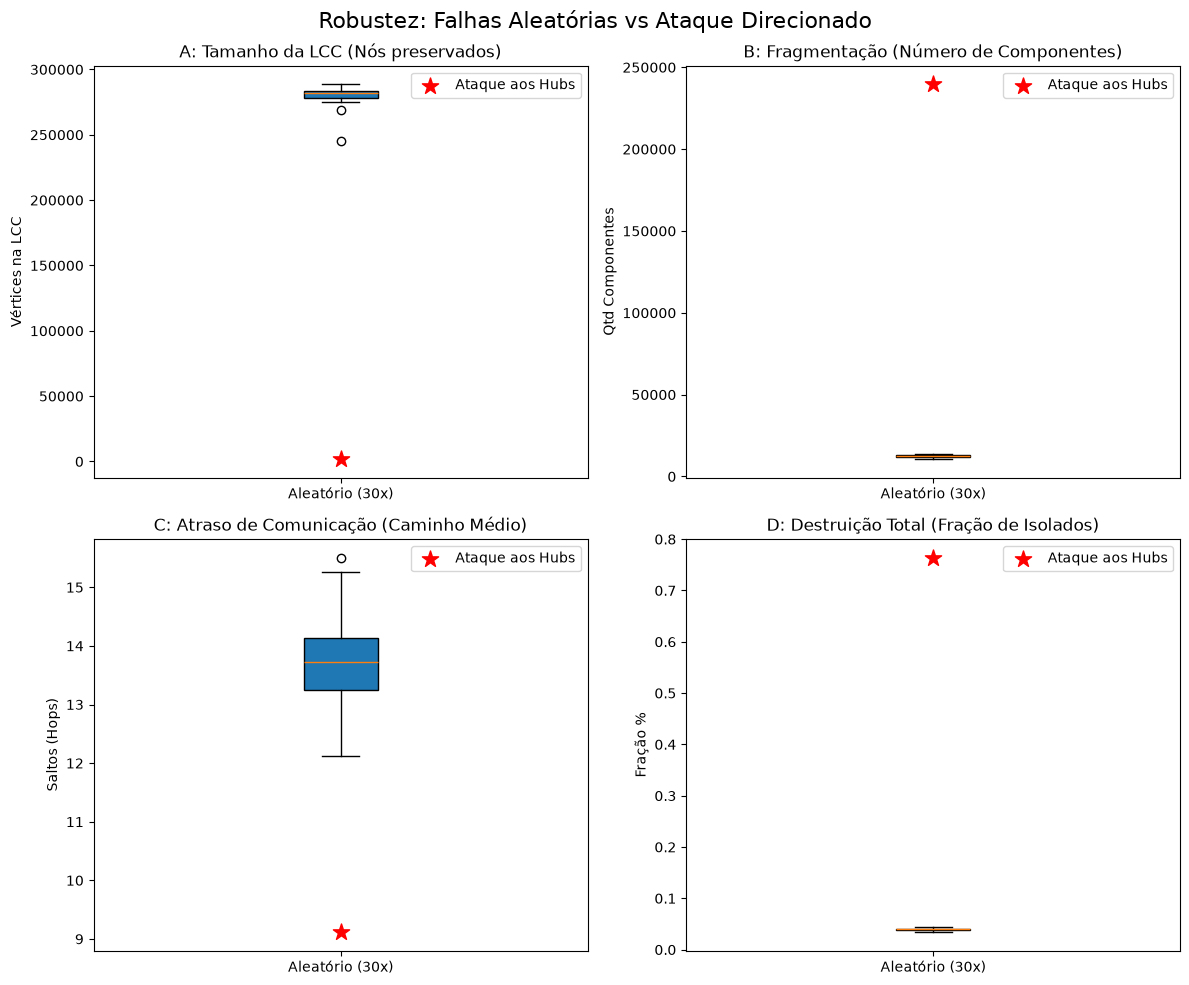

In [4]:
r = int(0.05 * N)
T = 30
metrics_rand = {'A': [], 'B': [], 'C': [], 'D': []}

print(f"Destruindo {r} nós aleatórios em {T} rodadas...")
nodes_list = list(LCC.nodes())

for t in range(T):
    G_fail = LCC.copy()
    to_remove = random.sample(nodes_list, r)
    G_fail.remove_nodes_from(to_remove)
    
    cc = list(nx.connected_components(G_fail))
    if cc:
        lcc_fail = max(cc, key=len)
        A = len(lcc_fail)
        C = approx_average_path_length(G_fail.subgraph(lcc_fail), 20)
    else:
        A = 0; C = 0
        
    B = len(cc)
    D = sum(1 for n in G_fail.nodes() if G_fail.degree(n) == 0) / G_fail.number_of_nodes() if G_fail.number_of_nodes() > 0 else 0
    
    metrics_rand['A'].append(A); metrics_rand['B'].append(B)
    metrics_rand['C'].append(C); metrics_rand['D'].append(D)

print("Realizando Ataque Direcionado aos 5% Top Hubs...")
sorted_nodes = sorted(LCC.degree(), key=lambda x: x[1], reverse=True)
hubs_to_remove = [n for n, d in sorted_nodes[:r]]

G_attack = LCC.copy()
G_attack.remove_nodes_from(hubs_to_remove)

cc_attack = list(nx.connected_components(G_attack))
if cc_attack:
    lcc_attack = max(cc_attack, key=len)
    A_att = len(lcc_attack)
    C_att = approx_average_path_length(G_attack.subgraph(lcc_attack), 20)
else:
    A_att = 0; C_att = 0
    
B_att = len(cc_attack)
D_att = sum(1 for n in G_attack.nodes() if G_attack.degree(n) == 0) / G_attack.number_of_nodes() if G_attack.number_of_nodes() > 0 else 0

print("\n--- RESULTADOS GERAIS DE ROBUSTEZ ---")
print(f"Tamanho da Maior Componente (A) - Aleatório: {np.mean(metrics_rand['A']):.1f} | Ataque: {A_att}")
print(f"Fracao de Nós Isolados (D)      - Aleatório: {np.mean(metrics_rand['D'])*100:.2f}% | Ataque: {D_att*100:.2f}%")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Robustez: Falhas Aleatórias vs Ataque Direcionado", fontsize=16)

def plot_box(ax, data, attack_val, title, ylabel):
    ax.boxplot(data, vert=True, patch_artist=True)
    ax.scatter([1], [attack_val], color='red', marker='*', s=150, zorder=5, label='Ataque aos Hubs')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks([1])
    ax.set_xticklabels(['Aleatório (30x)'])
    ax.legend()

plot_box(axes[0,0], metrics_rand['A'], A_att, 'A: Tamanho da LCC (Nós preservados)', 'Vértices na LCC')
plot_box(axes[0,1], metrics_rand['B'], B_att, 'B: Fragmentação (Número de Componentes)', 'Qtd Componentes')
plot_box(axes[1,0], metrics_rand['C'], C_att, 'C: Atraso de Comunicação (Caminho Médio)', 'Saltos (Hops)')
plot_box(axes[1,1], metrics_rand['D'], D_att, 'D: Destruição Total (Fração de Isolados)', 'Fração %')

plt.tight_layout()
plt.show()

### Síntese das Descobertas e Modelos Clássicos
Baseado nos resultados empíricos extraídos matemática e estatisticamente ao longo deste notebook, podemos responder e justificar as duas questões teóricas finais do projeto. As respostas se encontram desenvolvidas no relatório.